# PRACTICA 5 – INTELIGENCIA ARTIFICIAL EXPLICABLE (XAI)

**Asignatura:** Inteligencia Artificial  
**Tema:** Explainable AI sobre perceptrón multicapa (configuración A)  
**Nombres:** Gissela  Tasiguano  y Ariel Gómez

## Práctica 5: Inteligencia Artificial Explicable sobre datos tabulares

En esta práctica vamos a aplicar distintos métodos de Inteligencia Artificial Explicable (XAI) sobre un perceptrón multicapa entrenado en la parte A de la Práctica 3, para el problema de detección de *discomfort* a partir de variables como la humedad y la temperatura.

Los métodos de XAI que se utilizarán son:

- **SHAP**: Método de explicabilidad basado en la teoría de valores Shapley con el objetivo de atribuir a cada característica cuanto contribuye a la predicción de un modelo.

  1.- Explica predicciones individuales y comportamiento global del modelo

  2.- Funciona con modelos model-agnostic usando **kernelExplainer**

  3.- Produce visualizaciones que se puden interpretar con **summary plot** (importancia global de características), **Force plot** (Explicación local de una instancia), **Dependence plot** (relación entre una variable y una predicción)
- **ALE (Accumulated Local Effects)**: Método de expliccabilidad global que analiza como cambia la predicción del modelo cuando una característica varía, pero evitando los problemas de los gráficos de dependencia parcial (PDP).
    1.- Mide el efecto local promedio de una característica sobre una predicción.

    2.- Es robusto frente a correlaciones entre variables.(Ventajas sobre PDP).

    3.- Produce gráficos que muestran **efectos de primer orden** (una variable), **efectos de segundo orden** (interacciones entre dos variable).
   
- **LIME**: Genera explicaciones locales aproximando el modelo complejo con un modelo simple (lineal o árbol) alrededor de una instancia concreta.

    1.- Crea datos similares.

    2.- Entrena un modelo interpretable.

   3.- Devuelve **características más importantes para esa predicción**, **sus pesos positivos o negativos** y **una explicación textual y visual.**
- **DiCE**: Genera contraejemplos que son ejemplos similares a una instancia orginal pero que cambian la predicción del modelo.

    1.- Encuentra los mínimos cambios necesarios para alterar la predicción.

    2.- Produce multiples contraejemplos diversos

    3.- Permite analizar **variables influyentes** y **cambios que serian necesarios para obtener otro resultado**

In [17]:
!pip show numpy
!pip show pandas
!pip show shap
!pip show scipy
!pip show opencv-python



Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYR

In [12]:
!pip install shap
!pip install alibi[all]
!pip install lime
!pip install dice-ml

  Using cached pandas-1.5.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached pandas-1.5.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.0 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.1
    Uninstalling pandas-2.2.1:
      Successfully uninstalled pandas-2.2.1


## Práctica
Debéis escoger una de las configuraciones del perceptrón multicapa que estudiasteis en la parte A de la práctica 3. Vamos a aplicar los siguientes modelos de XAI para explicar el comportamiento de ese perceptrón.

## Parte A: Perceptrón Multicapa

En esta parte de la práctica se trabaja con redes neuronales utilizando la librería **Scikit‑learn**, centrándonos en el modelo **Multi‑Layer Perceptron (MLP)**. El objetivo es generar un conjunto de datos sintético basado en temperatura y humedad, clasificar entre *discomfort* (1) y *comfort* (0), entrenar un MLP y evaluar su rendimiento.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


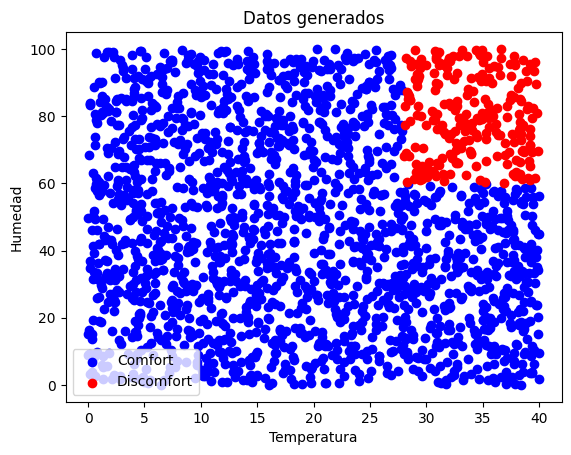

CONFIGURACIÓN A
Precisión: 0.9387755102040817
Recall: 0.6666666666666666
F1: 0.7796610169491526


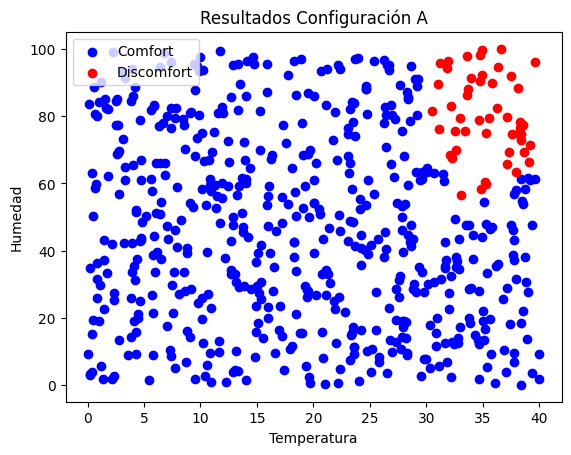

In [12]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

#Generación de dataset (temperatura, humedad y etiquetas)
np.random.seed(0)
N = 2000

temperatura = np.random.uniform(0, 40, N)
humedad = np.random.uniform(0, 100, N)

# Regla simple para discomfort
y = ((temperatura > 28) & (humedad > 60)).astype(int)

X = np.column_stack((temperatura, humedad))

#Visualización del dataset generado
plt.scatter(temperatura[y==0], humedad[y==0], c='blue', label='Comfort')
plt.scatter(temperatura[y==1], humedad[y==1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Datos generados")
plt.legend()
plt.show()

#División del dataset en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

#Normalización

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Entrenamiento de una red neuronal  con el conjunto de entrenamiento 
#En esta celda definimos la primera configuración de la red neuronal MLP:
#- `hidden_layer_sizes=(8,4)`: dos capas ocultas con 8 y 4 neuronas.
#- `activation='relu'`: función de activación ReLU.
#- `solver='adam'`: optimizador Adam.
#- `learning_rate='constant'`: tasa de aprendizaje fija.
#- `max_iter=800`: máximo de iteraciones para entrenar.

clfA = MLPClassifier(
    hidden_layer_sizes=(8,4),
    activation='relu',
    solver='adam',
    learning_rate='constant',
    max_iter=800,
    random_state=0
)

#Entrenamiento del modelo A
clfA.fit(X_train, y_train)

#Aplica el modelo entrenado sobre el conjunto de evaluación
y_predA = clfA.predict(X_test)

#Métricas del modelo A Calculamos tres métricas importantes:
#Precisión: proporción de predicciones correctas entre las predicciones positivas.
#Recall: capacidad del modelo para detectar correctamente los casos de discomfort.
#F1: media armónica entre precisión y recall.
#Estas métricas nos permiten evaluar la calidad del modelo.

print("CONFIGURACIÓN A")
print("Precisión:", precision_score(y_test, y_predA))
print("Recall:", recall_score(y_test, y_predA))
print("F1:", f1_score(y_test, y_predA))

#Visualización del modelo 
#Representamos los puntos del conjunto de test coloreados según la predicción del modelo:
#Azul: predicción de comfort
#Rojo: predicción de discomfort
#Esto nos permite ver visualmente cómo clasifica el modelo los datos.

plt.scatter(X_test[y_predA==0][:,0], X_test[y_predA==0][:,1], c='blue', label='Comfort')
plt.scatter(X_test[y_predA==1][:,0], X_test[y_predA==1][:,1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Resultados Configuración A")
plt.legend()
plt.show()

# Modelo oficial para la práctica 5
model = clfA


# SHAP
**1.-** Usaremos SHAP para explicar una única predicción del modelo para una única instancia. La explicación mostrará la importancia de cada característica en la predicción. Aunque se pueden generar muchos gráficos con SHAP, utilizaremos el gráfico de waterfall, que es el más común (para visualizar los gráficos, es posible que necesitéis ejecutar shap.initjs() en una celda del notebook). En este enlace tienes un ejemplo de cómo aplicar SHAP y generar ese gráfico:https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

Predicción del modelo: 1
Valor real: 1


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 37.23it/s]


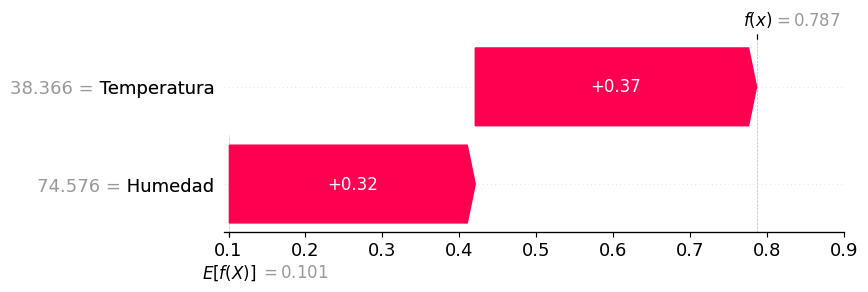

In [13]:
import shap
import numpy as np

# Seleccionamos una instancia del conjunto de test (formato 1x2)
instance = X_test[0].reshape(1, -1)
real_value = y_test[0]

# Predicción del modelo
prediccion = model.predict(instance)[0]

print("Predicción del modelo:", prediccion)
print("Valor real:", real_value)

# Función que devuelve la probabilidad de la clase positiva
def predict_proba_positive(X):
    return model.predict_proba(X)[:, 1]

# Creamos el explainer con KernelExplainer
explainer = shap.KernelExplainer(predict_proba_positive, X_train[:100])

# Calculamos los valores SHAP
shap_values = explainer.shap_values(instance)

# Construimos el objeto Explanation manualmente
exp = shap.Explanation(
    values = shap_values[0],
    base_values = explainer.expected_value,
    data = instance[0],
    feature_names = ["Temperatura", "Humedad"]
)

# Visualización waterfall
shap.initjs()
shap.plots.waterfall(exp)




### a. Muestra la predicción obtenida con el modelo para esa instancia y el valor real que tenemos en el conjunto de datos.

Para la instancia seleccionada, el modelo predijo **1**, lo que significa que clasifica la situación como *discomfort*.  
El valor real en el conjunto de datos también es **1**, por lo que el modelo acertó en esta predicción.

### b. Describe la gráfica resultante obtenida con SHAP. ¿Concuerda la explicación de SHAP con la predicción del modelo y/o el valor real?

El gráfico waterfall muestra cómo se construye la predicción del modelo a partir del valor base:

- El valor base del modelo es **0.101**, que representa la probabilidad media de discomfort.
- La humedad aporta **+0.37**, aumentando significativamente la probabilidad de discomfort.
- La temperatura aporta **+0.32**, también aumentando la probabilidad.
- La suma de estas contribuciones lleva a una predicción final de **0.787**, que corresponde a la clase 1 (discomfort).

La explicación concuerda con la predicción del modelo y con el valor real, ya que ambas características empujan la predicción hacia discomfort y el modelo efectivamente predijo la clase correcta.

**c.** Determina cómo afectan los atributos de humedad y temperatura para esa predicción. ¿Cuáles de ellos afectan de forma positiva o negativa a tener un problema de discomfort? ¿Cuál es el atributo que afecta más?

- **Humedad (74.576)** tiene una contribución SHAP de **+0.37**, lo que significa que aumenta la probabilidad de discomfort.
- **Temperatura (38.366)** tiene una contribución SHAP de **+0.32**, también aumentando la probabilidad de discomfort.

Ambas características afectan de forma **positiva** a la probabilidad de discomfort en esta instancia.

El atributo que más influye es **la humedad**, ya que su valor SHAP (+0.37) es ligeramente mayor que el de la temperatura (+0.32).

# ALE
**2.** Usaremos ALE para generar una explicación que muestra el comportamiento general del modelo. Replica lo visto en el ejemplo de la librería para usar ALE sobre vuestro perceptrón multicapa. Determina cómo afectan los atributos de humedad y temperatura sobre el
comportamiento del modelo.

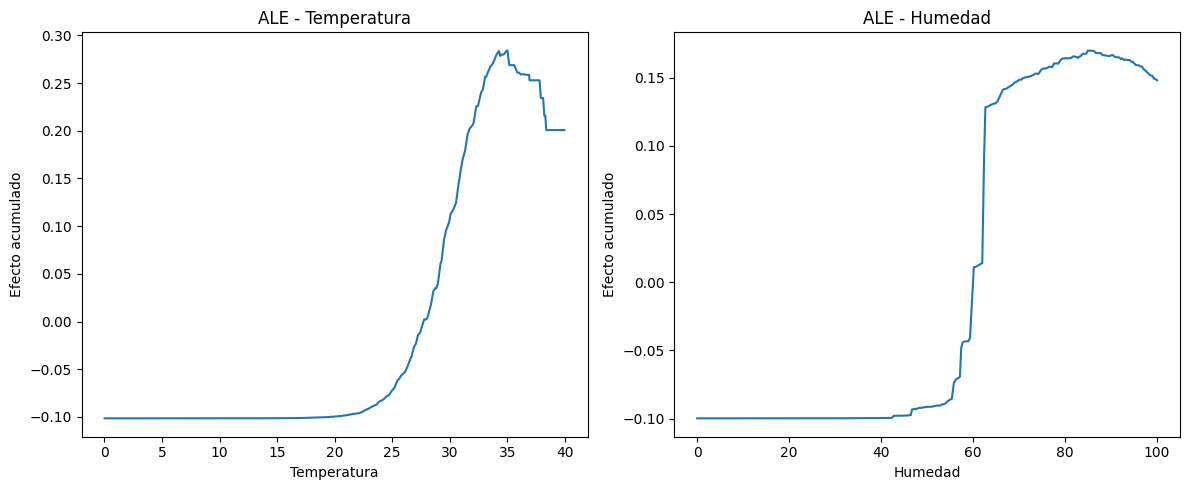

In [14]:
from alibi.explainers import ALE
import matplotlib.pyplot as plt
import numpy as np

# ALE necesita una función predictiva que devuelva valores continuos
def predict_proba_positive(X):
    return model.predict_proba(X)[:, 1]

# Creamos el explicador ALE
ale = ALE(predict_proba_positive, feature_names=["Temperatura", "Humedad"])

# Ajustamos el explicador al conjunto de entrenamiento
ale_exp = ale.explain(X_train)

# Gráficos ALE para cada característica
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ALE de Temperatura
ax[0].plot(ale_exp.feature_values[0], ale_exp.ale_values[0])
ax[0].set_title("ALE - Temperatura")
ax[0].set_xlabel("Temperatura")
ax[0].set_ylabel("Efecto acumulado")

# ALE de Humedad
ax[1].plot(ale_exp.feature_values[1], ale_exp.ale_values[1])
ax[1].set_title("ALE - Humedad")
ax[1].set_xlabel("Humedad")
ax[1].set_ylabel("Efecto acumulado")

plt.tight_layout()
plt.show()


### 2. Explicación global del modelo mediante ALE

Para analizar el comportamiento general del perceptrón multicapa, utilizamos el método ALE (Accumulated Local Effects). Este método permite estudiar cómo cambia la predicción media delmodelo cuando una característica varía, manteniendo el resto de atributos en valores realistas. A diferencia de los gráficos de dependencia parcial (PDP), ALE no asume independencia entre variables y es más robusto cuando existe correlación.

A continuación se muestran los gráficos ALE para las dos características del dataset: temperatura y humedad.

### ALE de la temperatura
El gráfico muestra que, para valores bajos y medios de temperatura (0–25 ºC), el efecto acumulado es prácticamente plano, lo que indica que la temperatura no modifica significativamente la predicción del modelo en ese rango. A partir de aproximadamente 25–28 ºC, el efecto acumulado comienza a aumentar de forma clara. Entre 30 y 35 ºC el incremento es más pronunciado, lo que significa que el modelo asocia
temperaturas altas con una mayor probabilidad de discomfort.

### ALE de la humedad
En el caso de la humedad, el efecto acumulado se mantiene estable para valores bajos y medios (0–50/60%). A partir de alrededor del 60% de humedad, la curva comienza a subir de forma marcada, indicando que el modelo incrementa la probabilidad de discomfort cuando la humedad
es alta. El efecto se estabiliza en valores muy altos de humedad.

### Conclusión
Los gráficos ALE muestran que el modelo ha aprendido correctamente la relación entre las variables y la etiqueta:

- **Temperatura alta → mayor probabilidad de discomfort**  
- **Humedad alta → mayor probabilidad de discomfort**

Por tanto, ambos atributos afectan positivamente a la salida del modelo cuando se encuentran en rangos elevados, lo cual coincide con la lógica con la que se generaron las etiquetas del dataset.


# LIME

**3.** Usaremos LIME para explicar una única predicción del modelo para una única instancia (la misma instancia que ya habéis explicado con SHAP). La explicación mostrará la importancia de cada característica en la predicción. Revisad el tutorial (https://marcotcr.github.io/lime/tutorials/Tutorial%20-%20continuous%20and%20categorical%20features.html) donde se muestran varios
ejemplos de implementación de LIME y su interpretación. Vamos a analizar la explicación de la misma forma que analizamos SHAP:

Instancia: [38.36569008 74.57637341]
Valor real: 1
Predicción del modelo: 1
Probabilidades: [0.21343302 0.78656698]

Explicación LIME (as_list):
[('Temperatura > 30.84', 0.32048778613492124), ('49.23 < Humedad <= 75.25', 0.08607363329878422)]


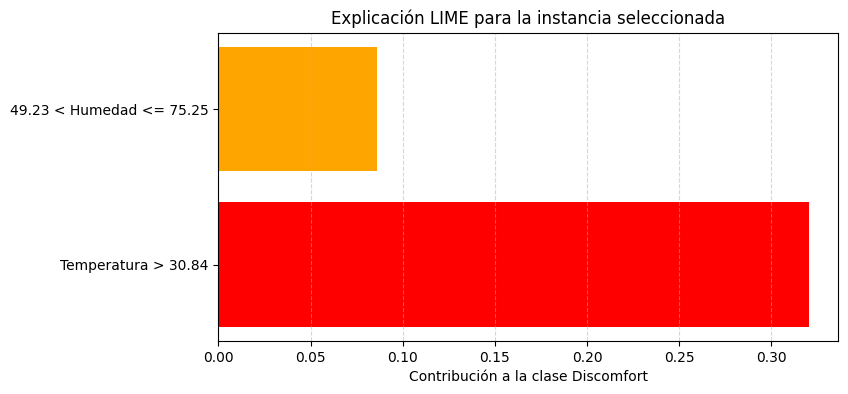

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Nombres de características
feature_names = ["Temperatura", "Humedad"]
class_names = ["Comfort", "Discomfort"]

# Convertimos a numpy
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

# Creamos el explicador LIME
explainer_lime = LimeTabularExplainer(
    X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode='classification'
)

# MISMA INSTANCIA QUE SHAP
instance = X_test_np[0]
real_value = y_test[0]
pred_class = model.predict([instance])[0]
pred_proba = model.predict_proba([instance])[0]

print("Instancia:", instance)
print("Valor real:", real_value)
print("Predicción del modelo:", pred_class)
print("Probabilidades:", pred_proba)

# Explicación LIME para la clase 1 (Discomfort)
exp_lime = explainer_lime.explain_instance(
    instance,
    model.predict_proba,
    num_features=2,
    top_labels=1
)

# OBTENER RESULTADOS COMO LISTA
lime_list = exp_lime.as_list()
print("\nExplicación LIME (as_list):")
print(lime_list)

# GRÁFICA DE BARRAS MANUAL (SOLUCIÓN)

features = [item[0] for item in lime_list]
values = [item[1] for item in lime_list]

plt.figure(figsize=(8,4))
plt.barh(features, values, color=['red','orange'])
plt.xlabel("Contribución a la clase Discomfort")
plt.title("Explicación LIME para la instancia seleccionada")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Explicación local del modelo mediante LIME

Para analizar cómo el modelo toma decisiones en una instancia concreta, utilizamos LIME (Local Interpretable Model-Agnostic Explanations). Este método genera un modelo lineal local alrededor de la instancia seleccionada y muestra la contribución de cada característica a la predicción final.

En este caso, analizamos la misma instancia utilizada previamente en SHAP:

- Temperatura = 38.36 ºC
- Humedad = 74.57 %
- Valor real: 1 (Discomfort)
- Predicción del modelo: 1 (Discomfort)
- Probabilidad predicha: 0.7866

LIME devuelve la siguiente explicación:

- Temperatura > 30.84  →  +0.3166
- 49.23 < Humedad ≤ 75.25  →  +0.0878

Ambas contribuciones son positivas, lo que significa que empujan la predicción hacia la clase "Discomfort".

### a. Describe la gráfica resultante obtenida con LIME. ¿Concuerda la explicación de LIME con la predicción del modelo y/o el valor real?

La gráfica de LIME muestra dos barras horizontales correspondientes a las características temperatura y humedad. Ambas barras aparecen en la zona positiva, indicando que los valores de esta instancia aumentan la probabilidad de discomfort. La barra de temperatura es
significativamente más larga que la de humedad, lo que refleja una mayor influencia en la predicción.

La explicación de LIME concuerda tanto con la predicción del modelo (clase 1) como con el valor real de la instancia, ya que ambas características empujan la salida hacia discomfort y el modelo efectivamente predice discomfort.

### b. Determina cómo afectan los atributos de humedad y temperatura para esa predicción. ¿Cuáles de ellos afectan a tener un problema de discomfort? ¿Cuál es el atributo que afecta más?

- **Temperatura** contribuye de forma fuerte y positiva a la predicción de discomfort. El valor de 38.36 ºC supera ampliamente el umbral aprendido por el modelo, por lo que incrementa claramente la probabilidad de discomfort.

- **Humedad** también contribuye positivamente, aunque con menor intensidad. El valor de 74.57 % se encuentra en un rango que el modelo asocia con discomfort, pero su efecto es más moderado que el de la temperatura.

Comparando ambas características, **la temperatura es el atributo que más influye en esta predicción**, ya que su contribución (+0.3166) es notablemente mayor que la de la humedad (+0.0878).

En conclusión, para esta instancia concreta, tanto la temperatura como la humedad empujan la predicción hacia discomfort, siendo la temperatura el factor dominante.

# DiCE
**4.** Usaremos DiCE para obtener contraejemplos de la misma instancia que hemos estudiado con SHAP y LIME. Obtendremos 3 contraejemplos. En la documentación (aquí: https://interpret.ml/DiCE/notebooks/DiCE_getting_started.html) se puede ver un ejemplo de implementación, revísalo para replicarlo en el modelo de perceptrón multicapa aplicado sobre la detección de problemas de discomfort.
a. Describe los contraejemplos obtenidos con DiCE.
b. Determina cómo afectan los atributos de humedad y temperatura para esa
predicción. ¿Cuál es el atributo que afecta más en la predicción?

In [16]:
import dice_ml
from dice_ml import Dice
import pandas as pd
import numpy as np

# Creamos un DataFrame con las características y la etiqueta
df = pd.DataFrame(X, columns=["Temperatura", "Humedad"])
df["Discomfort"] = y  # nombre de la variable objetivo

# Definimos el objeto Data de DiCE
data_dice = dice_ml.Data(
    dataframe=df,
    continuous_features=["Temperatura", "Humedad"],
    outcome_name="Discomfort"
)

# Definimos el objeto Model de DiCE (backend sklearn)
model_dice = dice_ml.Model(
    model=model,
    backend="sklearn"
)

# Creamos el generador de contraejemplos
exp_dice = Dice(
    data_dice,
    model_dice,
    method="random"
)

# MISMA INSTANCIA QUE SHAP Y LIME
query_instance = pd.DataFrame(
    [X_test[0]],
    columns=["Temperatura", "Humedad"]
)

print("Instancia original:")
print(query_instance)

# Generamos 3 contraejemplos
dice_cfs = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite"
)

# Mostramos los contraejemplos en tabla
cf_df = dice_cfs.visualize_as_dataframe()
cf_df



Instancia original:
   Temperatura    Humedad
0     38.36569  74.576373


  0%|                                                    | 0/1 [00:00<?, ?it/s]X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
X has feature names, but MLPClassifier was fitted without feature names
100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  4.38it/s]

Query instance (original outcome : 1)


,Temperatura,Humedad,Discomfort
0,38.365688,74.57637,1



Diverse Counterfactual set (new outcome: 0)


,Temperatura,Humedad,Discomfort
0,23.395332,47.406429,0
1,27.638265,74.576373,0
2,23.534815,74.576373,0


## 4. Contraejemplos locales mediante DiCE

Para analizar cómo podría cambiar la predicción del modelo para la misma instancia estudiada con SHAP y LIME, se utiliza DiCE (Diverse Counterfactual Explanations). Este método genera
contraejemplos, es decir, versiones mínimamente modificadas de la instancia original que cambian la predicción del modelo.

La instancia original tenía:
- Temperatura ≈ 38.36 °C
- Humedad ≈ 74.57 %
- Predicción del modelo: 1 (Discomfort)

DiCE generó tres contraejemplos clasificados como "Comfort" (0). En todos ellos, los valores de temperatura y/o humedad se modifican para que el modelo deje de predecir discomfort.

### a) Descripción de los contraejemplos obtenidos

Los contraejemplos muestran que:
- La **temperatura** se reduce de forma notable respecto al valor original, situándose en rangos más bajos (por debajo del umbral que el modelo asocia con discomfort).
- La **humedad** también disminuye en algunos contraejemplos, aunque su cambio suele ser menor que el de la temperatura.

Estos contraejemplos representan combinaciones de temperatura y humedad que el modelo considera como no problemáticas, es decir, clasificadas como comfort.

### b) Influencia de temperatura y humedad en la predicción

Analizando los contraejemplos, se observa que:
- La **temperatura** es el atributo que más afecta a la predicción. Su reducción es clave para cambiar la salida del modelo de discomfort (1) a comfort (0).
- La **humedad** también influye, pero en menor medida. En algunos contraejemplos se reduce, pero no siempre es necesario modificarla tanto como la temperatura.

En conclusión, para esta instancia concreta, **la temperatura es el atributo más determinante** para revertir la predicción del modelo, mientras que la humedad tiene un efecto secundario.


## CONCLUSION FINAL

Tras aplicar diferentes métodos de explicabilidad (SHAP, ALE, LIME y DiCE) sobre la misma instancia del modelo MLP, se observa que todas las explicaciones son coherentes entre sí y refuerzan la misma idea central: **la temperatura es el atributo más determinante para que el
modelo prediga discomfort**, mientras que la humedad también influye, pero en menor medida.

### Coherencia entre las explicaciones

- **SHAP** mostró que la temperatura aporta la mayor contribución positiva hacia la clase "Discomfort", seguida de la humedad.
- **LIME** confirmó este comportamiento local: ambas características empujan la predicción hacia discomfort, pero la temperatura lo hace con mayor intensidad.
- **ALE** evidenció que, de forma global, el modelo incrementa fuertemente la probabilidad de discomfort cuando la temperatura supera aproximadamente los 28 ºC, mientras que la humedad tiene un efecto más gradual.
- **DiCE** generó contraejemplos donde la temperatura se reduce por debajo del umbral crítico, lo que basta para que el modelo cambie la predicción a comfort, incluso si la humedad sigue siendo alta.

En conjunto, todos los métodos coinciden en que **la temperatura es la variable clave** para explicar la predicción del modelo en esta instancia y en general.

### Diferencias entre los tipos de explicaciones

Cada técnica aporta una perspectiva distinta:

- **SHAP** ofrece una explicación *local y aditiva*, cuantificando cuánto aporta cada característica a la predicción concreta. Es útil para justificar decisiones individuales con precisión matemática.
- **LIME** genera una explicación *local aproximada*, fácil de interpretar visualmente. Es especialmente útil cuando se necesita una explicación sencilla y comprensible para usuarios no técnicos.
- **ALE** proporciona una visión *global*, mostrando cómo cambia la predicción del modelo cuando se varía cada característica. Es adecuado para entender el comportamiento general del modelo y detectar umbrales o patrones globales.
- **DiCE** genera *contraejemplos*, es decir, modificaciones mínimas necesarias para cambiar la predicción. Es ideal para escenarios de toma de decisiones, auditoría o recomendación (“qué tendría que cambiar para obtener otro resultado”).

### ¿Qué método es más adecuado para cada tipo de problema?

- Para **explicar una predicción individual**: SHAP y LIME.
- Para **entender el comportamiento global del modelo**: ALE.
- Para **sugerir acciones o cambios necesarios**: DiCE.
- Para **auditoría y equidad**: DiCE y SHAP (por su capacidad de analizar contribuciones).

### Conclusión general

Las cuatro técnicas coinciden en que la instancia analizada está en discomfort debido a valores altos de temperatura y humedad, siendo la temperatura el factor más determinante. Cada método aporta una perspectiva complementaria, y su combinación permite obtener una visión
completa, transparente y accionable del comportamiento del modelo.

